In [1]:
'''
Post-Approval Risk Modeling
Not all approved loans are good - some approved loans will be future defaulters. How do we model a machine learning model 
that efficiently predicts future defaulters based on historic financial data?
'''

'\nPost-Approval Risk Modeling\nNot all approved loans are good - some approved loans will be future defaulters. How do we model a machine learning model \nthat efficiently predicts future defaulters based on historic financial data?\n'

In [2]:
#libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

C:\Users\silom\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\silom\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
# importing dataset
df = pd.read_csv(r"accepted_2007_to_2018Q4.csv")

print(df.head(10))
print(df.describe().T)
print(df.shape)

C:\Users\silom\AppData\Local\Temp\ipykernel_31184\2598127639.py:2: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"accepted_2007_to_2018Q4.csv")


         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   
5  68426831        NaN    11950.0      11950.0          11950.0   36 months   
6  68476668        NaN    20000.0      20000.0          20000.0   36 months   
7  67275481        NaN    20000.0      20000.0          20000.0   36 months   
8  68466926        NaN    10000.0      10000.0          10000.0   36 months   
9  68616873        NaN     8000.0       8000.0           8000.0   36 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...     

In [4]:
# missing values

df.isnull().sum().sort_values(ascending = False)

member_id                                     2260701
orig_projected_additional_accrued_interest    2252050
hardship_end_date                             2249784
hardship_start_date                           2249784
hardship_type                                 2249784
                                               ...   
policy_code                                        33
revol_bal                                          33
fico_range_high                                    33
fico_range_low                                     33
id                                                  0
Length: 151, dtype: int64

In [5]:
# data cleaning

df.drop(columns = 'member_id')



,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,Vice President,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,Program Manager,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,Customer Service Technician,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


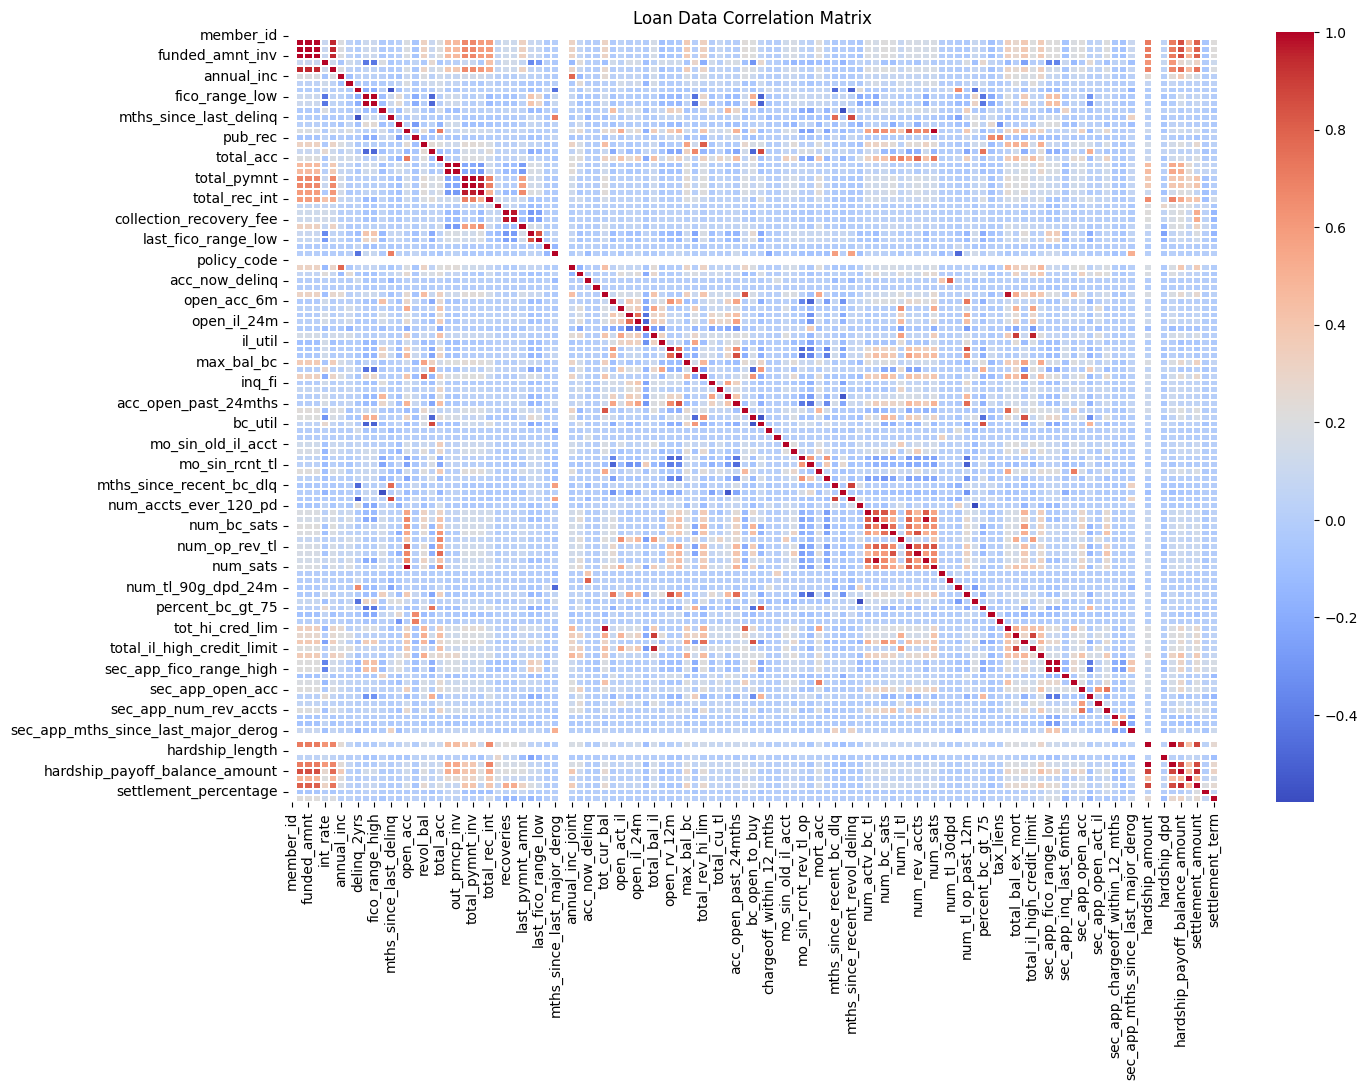

In [6]:
# Exploratory Data Analysis 
import seaborn as sns
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize = (15, 10))

sns.heatmap(corr_matrix, annot = False, cmap = 'coolwarm', linewidths = 0.1)

plt.title("Loan Data Correlation Matrix")
plt.show()



In [7]:
# further data cleaning/refining
"""
Capacity to pay: annual_inc, dti.
historical credit worthiness: fico_range_high, delinq_2yrs, pub_rec

"""
use_cols = [
    'loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 
    'fico_range_high', 'delinq_2yrs', 'open_acc', 'pub_rec', 'loan_status'
]
df = df[use_cols]

df.columns.to_list()

['loan_amnt',
 'term',
 'int_rate',
 'annual_inc',
 'dti',
 'fico_range_high',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'loan_status']

In [8]:
print(df.head())

df.isnull().sum().sort_values(ascending = False)

   loan_amnt        term  int_rate  annual_inc    dti  fico_range_high  \
0     3600.0   36 months     13.99     55000.0   5.91            679.0   
1    24700.0   36 months     11.99     65000.0  16.06            719.0   
2    20000.0   60 months     10.78     63000.0  10.78            699.0   
3    35000.0   60 months     14.85    110000.0  17.06            789.0   
4    10400.0   60 months     22.45    104433.0  25.37            699.0   

   delinq_2yrs  open_acc  pub_rec loan_status  
0          0.0       7.0      0.0  Fully Paid  
1          1.0      22.0      0.0  Fully Paid  
2          0.0       6.0      0.0  Fully Paid  
3          0.0      13.0      0.0     Current  
4          1.0      12.0      0.0  Fully Paid  


dti                1744
delinq_2yrs          62
open_acc             62
pub_rec              62
annual_inc           37
loan_amnt            33
term                 33
int_rate             33
fico_range_high      33
loan_status          33
dtype: int64

In [9]:
# Filter for historical records to validate unsupervised clusters later
df_historical = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_historical['is_defaulted'] = (df_historical['loan_status'] == 'Charged Off').astype(int)

df_sample = df_historical.sample(n=5000, random_state=42).reset_index(drop=True)

X = df_historical.drop(columns=['loan_status', "is_defaulted"]) # for the clustering model



In [10]:
# Importing Datasets for PCA, Hierarchical Clustering and Preprocessing Steps 

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import seaborn as sns 

In [11]:
# Imputing and Scaling Steps
X['term'] = X['term'].astype(str).str.extract('(\d+)').astype(float)

# 1. Imputing
imputer = SimpleImputer(strategy = 'median')
X_imputed = imputer.fit_transform(X)

#2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\silom\AppData\Local\Temp\ipykernel_31184\3017073545.py:2: SyntaxWarning: invalid escape sequence '\d'
  X['term'] = X['term'].astype(str).str.extract('(\d+)').astype(float)



 n_components: 7
Compressed feature dimensions from 9 down to 7 Principal Components.
Total Information (Explained Variance) Retained: 89.63%


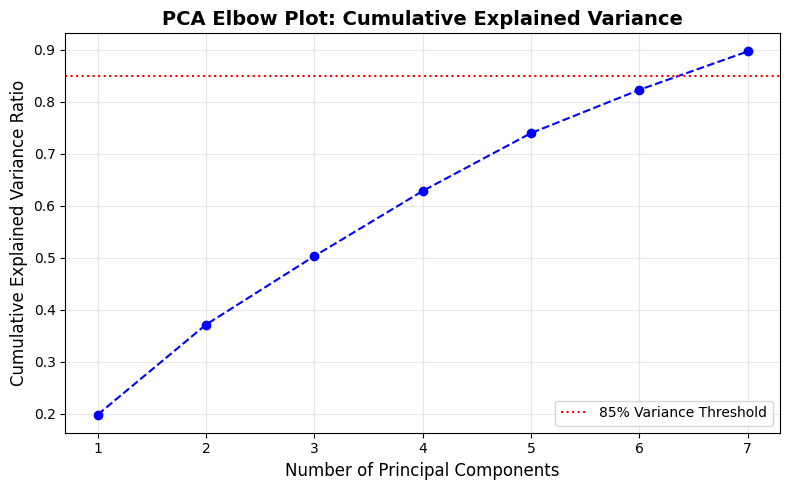

In [12]:
# PCA - Dimensionality reduction for computational reasons

pca = PCA(n_components = 0.85) # enough columns that explains 85% of the variance for our hierarchical clustering model

X_pca = pca.fit_transform(X_scaled)

n_comps = pca.n_components_
print(f"\n n_components: {n_comps}") 

print(f"Compressed feature dimensions from {X_scaled.shape[1]} down to {X_pca.shape[1]} Principal Components.")
print(f"Total Information (Explained Variance) Retained: {np.sum(pca.explained_variance_ratio_):.2%}")

# Using a PCA Visual Elbow Method to find the optimal number of dimensions for our clustering model

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')


plt.axhline(y=0.85, color='r', linestyle=':', label='85% Variance Threshold')

plt.title('PCA Elbow Plot: Cumulative Explained Variance', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()
# with the help of AI

In [13]:
print("Figure 1: PCA Cumulative Explained Variance.The elbow plot shows that the first 7 principal components capture over 85% of the total variance in the Lending Club application dataset. Beyond this point, adding more components yields diminishing returns, only introducing noise. By reducing our feature space to these top components, we eliminate multicollinearity and optimize the computational efficiency of our Hierarchical Clustering algorithm.")

Figure 1: PCA Cumulative Explained Variance.The elbow plot shows that the first 7 principal components capture over 85% of the total variance in the Lending Club application dataset. Beyond this point, adding more components yields diminishing returns, only introducing noise. By reducing our feature space to these top components, we eliminate multicollinearity and optimize the computational efficiency of our Hierarchical Clustering algorithm.


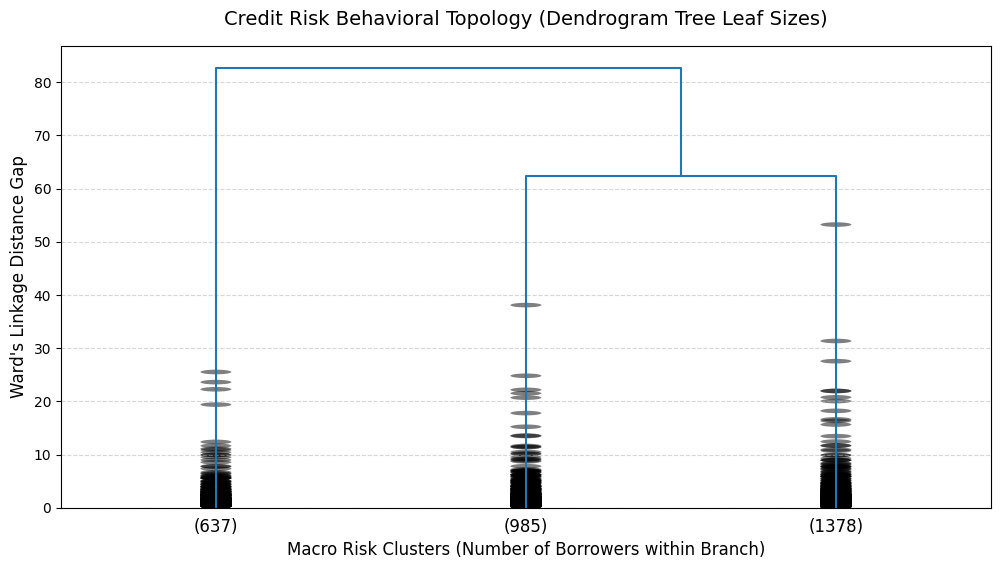

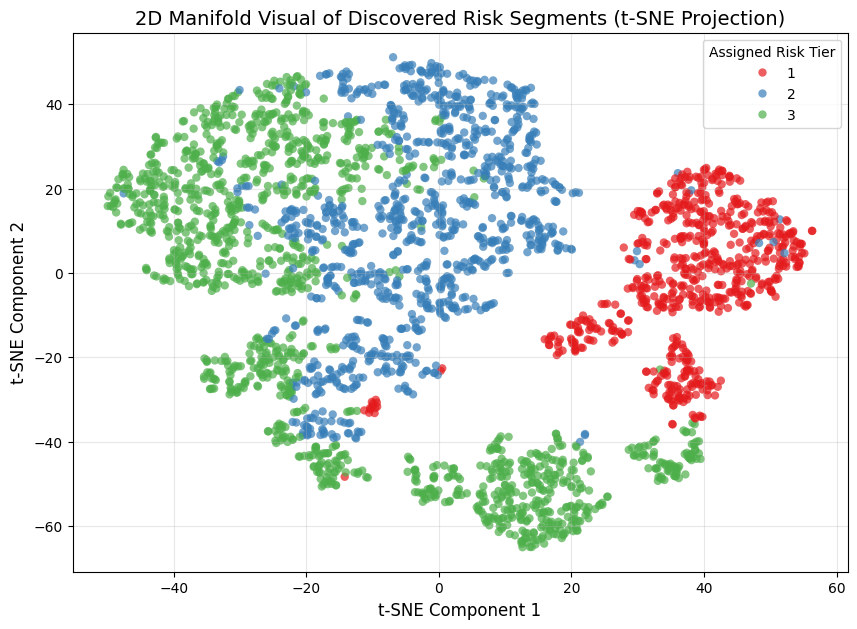

In [14]:
#Hierarchical Clustering - Model and Visuals
X_sample = X_pca[:3000]
Z = linkage(X_sample, method='ward')

# Generate Dendrogram for visual portfolio validation
plt.figure(figsize=(12, 6))
dendrogram(
    Z, 
    truncate_mode='lastp', 
    p=3,  # Cut visual tree display down to 3 distinct macro branches
    show_leaf_counts=True,
    leaf_rotation=0,
    leaf_font_size=12,
    show_contracted=True
)
plt.title("Credit Risk Behavioral Topology (Dendrogram Tree Leaf Sizes)", fontsize=14, pad=15)
plt.xlabel("Macro Risk Clusters (Number of Borrowers within Branch)", fontsize=12)
plt.ylabel("Ward's Linkage Distance Gap", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

tsne_sample_size = 3000
X_tsne_input = X_pca[:tsne_sample_size]

# 2. Run linkage specifically on this subset to guarantee row alignment
from scipy.cluster.hierarchy import linkage
Z_tsne_subset = linkage(X_tsne_input, method='ward')

# 3. Extract the 3 cluster labels directly from this aligned linkage matrix
tsne_clusters = fcluster(Z_tsne_subset, t=3, criterion='maxclust')

# 4. Project the same subset into 2D space
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_input)

# 5. Plot the cleanly aligned clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=tsne_clusters, palette='Set1', 
    alpha=0.7, edgecolor='none'
)
plt.title("2D Manifold Visual of Discovered Risk Segments (t-SNE Projection)", fontsize=14)
plt.xlabel("t-SNE Component 1", fontsize=12)
plt.ylabel("t-SNE Component 2", fontsize=12)
plt.legend(title="Assigned Risk Tier")
plt.grid(True, alpha=0.3)
plt.show()



In [21]:
# Mapping out hierarchical visuals to credit tier metrics using AI

df_validation = df_historical.iloc[:3000].copy()
df_validation['Cluster_ID'] = tsne_clusters

risk_profile_table = df_validation.groupby('Cluster_ID').agg(
    borrower_count=('loan_amnt', 'count'),
    avg_fico=('fico_range_high', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_loan_amt=('loan_amnt', 'mean'),
    avg_dti=('dti', 'mean'),
    actual_default_rate=('is_defaulted', 'mean') # Ground truth validation metric
).round(2)

# Convert default rate to a clean percentage string for presentation
risk_profile_table['actual_default_rate'] = (risk_profile_table['actual_default_rate'] * 100).astype(str) + '%'

print("=== FINAL RISK PROFILE & VALIDATION MATRIX ===")
print(risk_profile_table)


=== FINAL RISK PROFILE & VALIDATION MATRIX ===
            borrower_count  avg_fico  avg_int_rate  avg_loan_amt  avg_dti  \
Cluster_ID                                                                  
1                      637    698.25         16.03      21112.68    20.62   
2                      985    717.54          9.66      17100.53    19.04   
3                     1378    688.43         11.97      10119.05    18.77   

           actual_default_rate  
Cluster_ID                      
1                        35.0%  
2                        10.0%  
3                        16.0%  


In [16]:
"""
Cluster 1: "Danger Zone Borrowers" (Maximum Risk)
Cluster 2: "The safest borrowers" (Low Risk)
Cluster 3: "The Core Retail Borrowers" (Moderate Risk)
"""

'\nCluster 1: "Danger Zone Borrowers" (Maximum Risk)\nCluster 2: "The safest borrowers" (Low Risk)\nCluster 3: "The Core Retail Borrowers" (Moderate Risk)\n'

In [17]:
print(X.columns.to_list())

# A completely leak-proof pre-application matrix
print("use_cols:")

use_cols = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti', 
    'fico_range_high', 'open_acc', 'pub_rec', 'loan_status'
]

print(use_cols)

print("feature_cols:")

feature_cols = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti', 
    'fico_range_high', 'delinq_2yrs', 'open_acc', 'pub_rec'
]
# Run this temporary check to find the leak
df_check = df_sample[feature_cols].copy()
df_check['is_defaulted'] = df_sample['is_defaulted']
print(df_check.corr()['is_defaulted'].sort_values())

['loan_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'fico_range_high', 'delinq_2yrs', 'open_acc', 'pub_rec']
use_cols:
['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_high', 'open_acc', 'pub_rec', 'loan_status']
feature_cols:
fico_range_high   -0.151651
annual_inc        -0.053683
delinq_2yrs        0.000198
pub_rec            0.037472
dti                0.056153
open_acc           0.057943
loan_amnt          0.069700
int_rate           0.262008
is_defaulted       1.000000
Name: is_defaulted, dtype: float64


In [18]:
""" 
Biggest drivers of defaulting are: Interest Rate and Fico Score (Credit Score)
"""

' \nBiggest drivers of defaulting are: Interest Rate and Fico Score (Credit Score)\n'

C:\Users\silom\AppData\Local\Temp\ipykernel_31184\2134745398.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk Tier', y='Default Rate (%)', data=plot_data, ax=ax1, palette='Oranges_r', alpha=0.8)


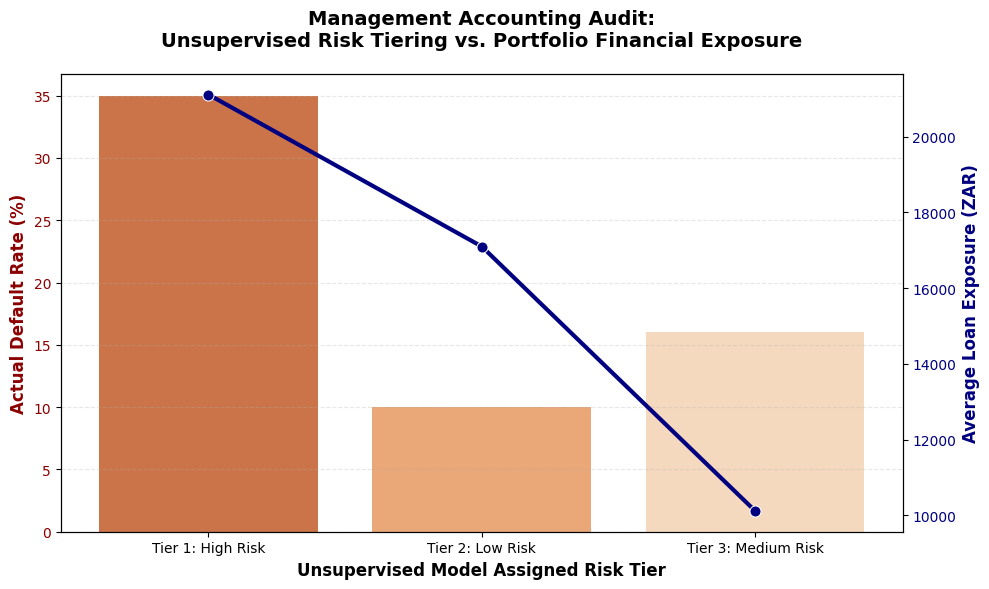

In [19]:
# Business Value Visual - AI Assistance


# 1. Convert our matrix numbers into a clean plotting dataframe
plot_data = pd.DataFrame({
    'Risk Tier': ['Tier 1: High Risk', 'Tier 2: Low Risk', 'Tier 3: Medium Risk'],
    'Default Rate (%)': [35.0, 10.0, 16.0],
    'Avg Loan Amount (R)': [21112.68, 17100.53, 10119.05]
})

# 2. Set up a dual-axis professional chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Default Rates
sns.barplot(x='Risk Tier', y='Default Rate (%)', data=plot_data, ax=ax1, palette='Oranges_r', alpha=0.8)
ax1.set_ylabel('Actual Default Rate (%)', fontsize=12, fontweight='bold', color='darkred')
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.set_xlabel('Unsupervised Model Assigned Risk Tier', fontsize=12, fontweight='bold')

# Line chart for Loan Exposure Size
ax2 = ax1.twinx()
sns.lineplot(x='Risk Tier', y='Avg Loan Amount (R)', data=plot_data, ax=ax2, color='navy', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Average Loan Exposure (ZAR)', fontsize=12, fontweight='bold', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title('Management Accounting Audit:\nUnsupervised Risk Tiering vs. Portfolio Financial Exposure', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('portfolio_risk_management_audit.png', dpi=300)
plt.show()
